In [1]:
import sys

sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data, label_column

# Settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

PALETTE = "#2563EB"  # primary blue

In [2]:
df, labels = load_data(replace_negatives=True)

print(f"Shape: {df.shape[0]} respondents × {df.shape[1]} variables")

Shape: 3510 respondents × 725 variables


In [3]:
w1_cols = [c for c in df.columns if c.startswith("w1_")]
w2_cols = [c for c in df.columns if c.startswith("w2_")]
w3_cols = [c for c in df.columns if c.startswith("w3_")]
other_cols = [c for c in df.columns if c not in w1_cols + w2_cols + w3_cols]

print(f"Wave 1 columns (w1_): {len(w1_cols)}")
print(f"Wave 2 columns (w2_): {len(w2_cols)}")
print(f"Wave 3 columns (w3_): {len(w3_cols)}")
print(f"Other columns:         {len(other_cols)}")
print(f"\nOther columns: {other_cols}")

Wave 1 columns (w1_): 199
Wave 2 columns (w2_): 193
Wave 3 columns (w3_): 191
Other columns:         142

Other columns: ['caseid_new', 'xpartner_type_cohab', 'yr_breakup_combo', 'change_in_rel_quality_w1w2', 'w1w2_sex_freq_diff', 'p17_core_emp', 'p17_ppcmdate2017', 'p17_pppa_lgb', 'p17_pppa1634', 'p17_pppa1635', 'p17_pppa1648', 'p17_ppp20072', 'p17_ppp20071', 'p17_ppp10206', 'p17_ppp10207', 'p17_ppp10208', 'p17_ppp10209', 'p17_ppp10210', 'p17_ppp10211', 'p17_ppp10212', 'p17_ppp10213', 'p17_pppa1704', 'p17_pppa1705', 'p17_pppadate2017', 'p17_ppfs0596', 'p17_ppfs1480', 'p17_ppfs1482', 'p17_ppfsdate2017', 'p18_core_emp', 'p18_ppmarit', 'p18_ppincimp', 'p18_ppcmdate2018', 'p18_pppa_lgb', 'p18_pppa1634', 'p18_pppa1635', 'p18_pppa1648', 'p18_ppp20072', 'p18_ppp20071', 'p18_ppp10206', 'p18_ppp10207', 'p18_ppp10208', 'p18_ppp10209', 'p18_ppp10210', 'p18_ppp10211', 'p18_ppp10212', 'p18_ppp10213', 'p18_pppa1704', 'p18_pppa1705', 'p18_pppa1802', 'p18_pppa1803', 'p18_pppadate2018', 'p18_ppfs0596'

In [4]:
print(df.dtypes.value_counts())

float64    725
Name: count, dtype: int64


In [5]:
df.head()

,caseid_new,w3_Weight,w3_Weight_LGB,w3_combo_weight,w3_attrition_adj_weight,w2_weight_genpop,w2_weight_LGB,w2_combo_weight,w2_attrition_adj_weights,w1_weight_combo,w1_weight_combo_freqwt,w3_xpartner_type,w3_xlast_contact_year,w3_xcohab,w3_xsamesex,w3_xlast_contact_mo,w3_xnamep_present,w3_duration,w3_gen_pop_sample,w3_ppage,w3_ppagecat,w3_ppagect4,w3_ppeduc,w3_ppeducat,w3_ppethm,...,p20_ppp10209,p20_ppp10210,p20_ppp10211,p20_ppp10212,p20_pppa1704,p20_pppa1705,p20_pppa1802,p20_pppa1803,p20_ppp12002,p20_ppp12003,p20_ppp12004,p20_ppp12005,p20_ppp10213,p20_ppp1date2020,p20_pppagnid,p20_pppa1634,p20_pppa1902,p20_pppa1903,p20_pppa1904,p20_ppp22001,p20_pppa1905,p20_pppa1648,p20_ppp20072,p20_ppp20071,p20_ppp2date2020
0,53001.0,0.4422,NaN,0.495308,0.400185,0.3856,NaN,0.437670,0.380351,0.426861,29628.0,2.0,2020.0,2.0,2.0,9.0,1.0,5.88,1.0,53.0,4.0,3.0,9.0,2.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20200913.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,13.0,6.0,NaN,20210506.0
1,71609.0,0.8284,NaN,0.927891,0.879258,0.9196,NaN,1.043778,0.953948,1.295508,89921.0,1.0,2020.0,1.0,2.0,9.0,1.0,10.47,1.0,72.0,6.0,4.0,10.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,20200917.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0,5.0,1.0,20201118.0
2,106983.0,0.8255,NaN,0.924643,0.706467,0.7748,NaN,0.879425,0.724682,1.126573,78196.0,1.0,2020.0,1.0,2.0,9.0,1.0,4.43,1.0,43.0,3.0,2.0,11.0,3.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20200910.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,20210429.0
3,121759.0,NaN,NaN,NaN,NaN,0.9177,NaN,1.041622,0.793093,0.933440,64790.0,1.0,2020.0,1.0,2.0,9.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20200917.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,11.0,2.0,1.0,20210507.0
4,158083.0,0.8810,NaN,0.986809,0.655467,0.8697,NaN,0.987140,0.735473,0.931291,64641.0,3.0,2020.0,NaN,NaN,9.0,0.0,5.34,1.0,53.0,4.0,3.0,10.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,20200916.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,13.0,6.0,NaN,20210602.0


In [6]:
# Missing values summary
missing_val = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print("Missing value distribution:")
print(f"  >90% missing:   {(missing_val > 90).sum()} columns")
print(f"  70-90% missing: {((missing_val > 70) & (missing_val <= 90)).sum()} columns")
print(f"  50-70% missing: {((missing_val > 50) & (missing_val <= 70)).sum()} columns")
print(f"  30-50% missing: {((missing_val > 30) & (missing_val <= 50)).sum()} columns")
print(f"  10-30% missing: {((missing_val > 10) & (missing_val <= 30)).sum()} columns")
print(f"  <10% missing:   {(missing_val < 10).sum()} columns")

Missing value distribution:
  >90% missing:   227 columns
  70-90% missing: 27 columns
  50-70% missing: 112 columns
  30-50% missing: 139 columns
  10-30% missing: 32 columns
  <10% missing:   188 columns


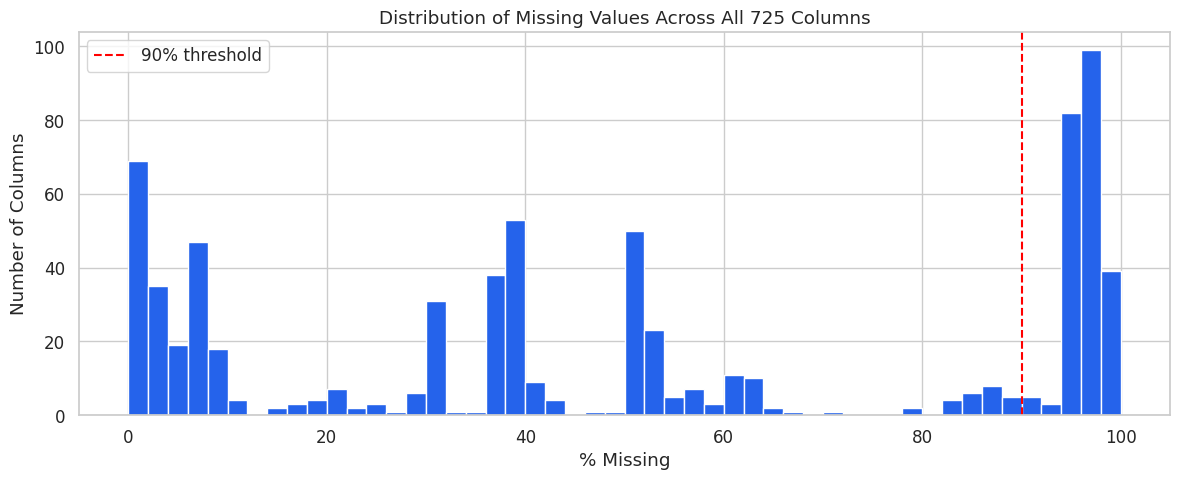

In [7]:
# Visualize missing data distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(missing_val, bins=50, color=PALETTE, edgecolor="white")
ax.set_xlabel("% Missing")
ax.set_ylabel("Number of Columns")
ax.set_title("Distribution of Missing Values Across All 725 Columns")
ax.axvline(x=90, color="red", linestyle="--", label="90% threshold")
ax.legend()
plt.tight_layout()
plt.show()

### Drop columns with 90% missing values

In [8]:
cols_before = df.shape[1]
cols_to_drop = missing_val[missing_val > 90].index.tolist()
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns with >90% missing values")
print(f"Remaining: {df.shape[1]} columns")

Dropped 227 columns with >90% missing values
Remaining: 498 columns


### Attrition Analysis
- The same people that were surveyed in 2017, 2020 and 2022 but not everyone came back. 

In [9]:
# Who responded to each wave?
in_w1 = pd.Series(True, index=df.index)
in_w2 = df["w2_combo_weight"].notna()
in_w3 = df["w3_combo_weight"].notna()

print("Respondents per wave:")
print(f"  Wave 1 (2017): {in_w1.sum():,} (100%)")
print(f"  Wave 2 (2020): {in_w2.sum():,} ({in_w2.mean():.0%})")
print(f"  Wave 3 (2022): {in_w3.sum():,} ({in_w3.mean():.0%})")
print(f"\nDropped between W1→W2: {(~in_w2).sum():,}")
print(f"Dropped between W2→W3: {(in_w2 & ~in_w3).sum():,}")

Respondents per wave:
  Wave 1 (2017): 3,510 (100%)
  Wave 2 (2020): 2,107 (60%)
  Wave 3 (2022): 1,722 (49%)

Dropped between W1→W2: 1,403
Dropped between W2→W3: 502


In [10]:
# Is attrition random? Compare demographics of those who stayed vs dropped
df["stayed_w3"] = in_w3.astype(int)

# Age
print("=== AGE ===")
print(f"  Stayed to W3:  mean age = {df.loc[in_w3, 'w1_ppage'].mean():.1f}")
print(f"  Dropped out:   mean age = {df.loc[~in_w3, 'w1_ppage'].mean():.1f}")

# Gender
print("\n=== GENDER ===")
for g, g_label in [(1, "Male"), (2, "Female")]:
    mask_g = df["w1_ppgender"] == g
    rate = in_w3[mask_g].mean()
    print(f"  {g_label}: {rate:.0%} stayed to W3")

# Education
print("\n=== EDUCATION ===")
edu_labels = labels.get("w1_ppeducat", {})
for e in sorted(df["w1_ppeducat"].dropna().unique()):
    mask_e = df["w1_ppeducat"] == e
    rate = in_w3[mask_e].mean()
    print(f"  {edu_labels.get(int(e), e)}: {rate:.0%} stayed to W3")

# Partnership status
print("\n=== PARTNERSHIP STATUS ===")
ps_labels = labels.get("w1_partnership_status", {})
for p in sorted(df["w1_partnership_status"].dropna().unique()):
    mask_p = df["w1_partnership_status"] == p
    rate = in_w3[mask_p].mean()
    print(f"  {ps_labels.get(int(p), p)}: {rate:.0%} stayed to W3")

df.drop(columns=["stayed_w3"], inplace=True)

=== AGE ===
  Stayed to W3:  mean age = 50.8
  Dropped out:   mean age = 46.9

=== GENDER ===
  Male: 54% stayed to W3
  Female: 44% stayed to W3

=== EDUCATION ===
  Less than high school: 41% stayed to W3
  High school: 48% stayed to W3
  Some college: 46% stayed to W3
  Bachelor's degree or higher: 54% stayed to W3

=== PARTNERSHIP STATUS ===
  married: 52% stayed to W3
  partnered, not married: 40% stayed to W3
  unpartnered, has had past partner: 50% stayed to W3
  never had a partner: 53% stayed to W3


/tmp/ipykernel_16380/2656550962.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["stayed_w3"] = in_w3.astype(int)


### Demographic Wave 1

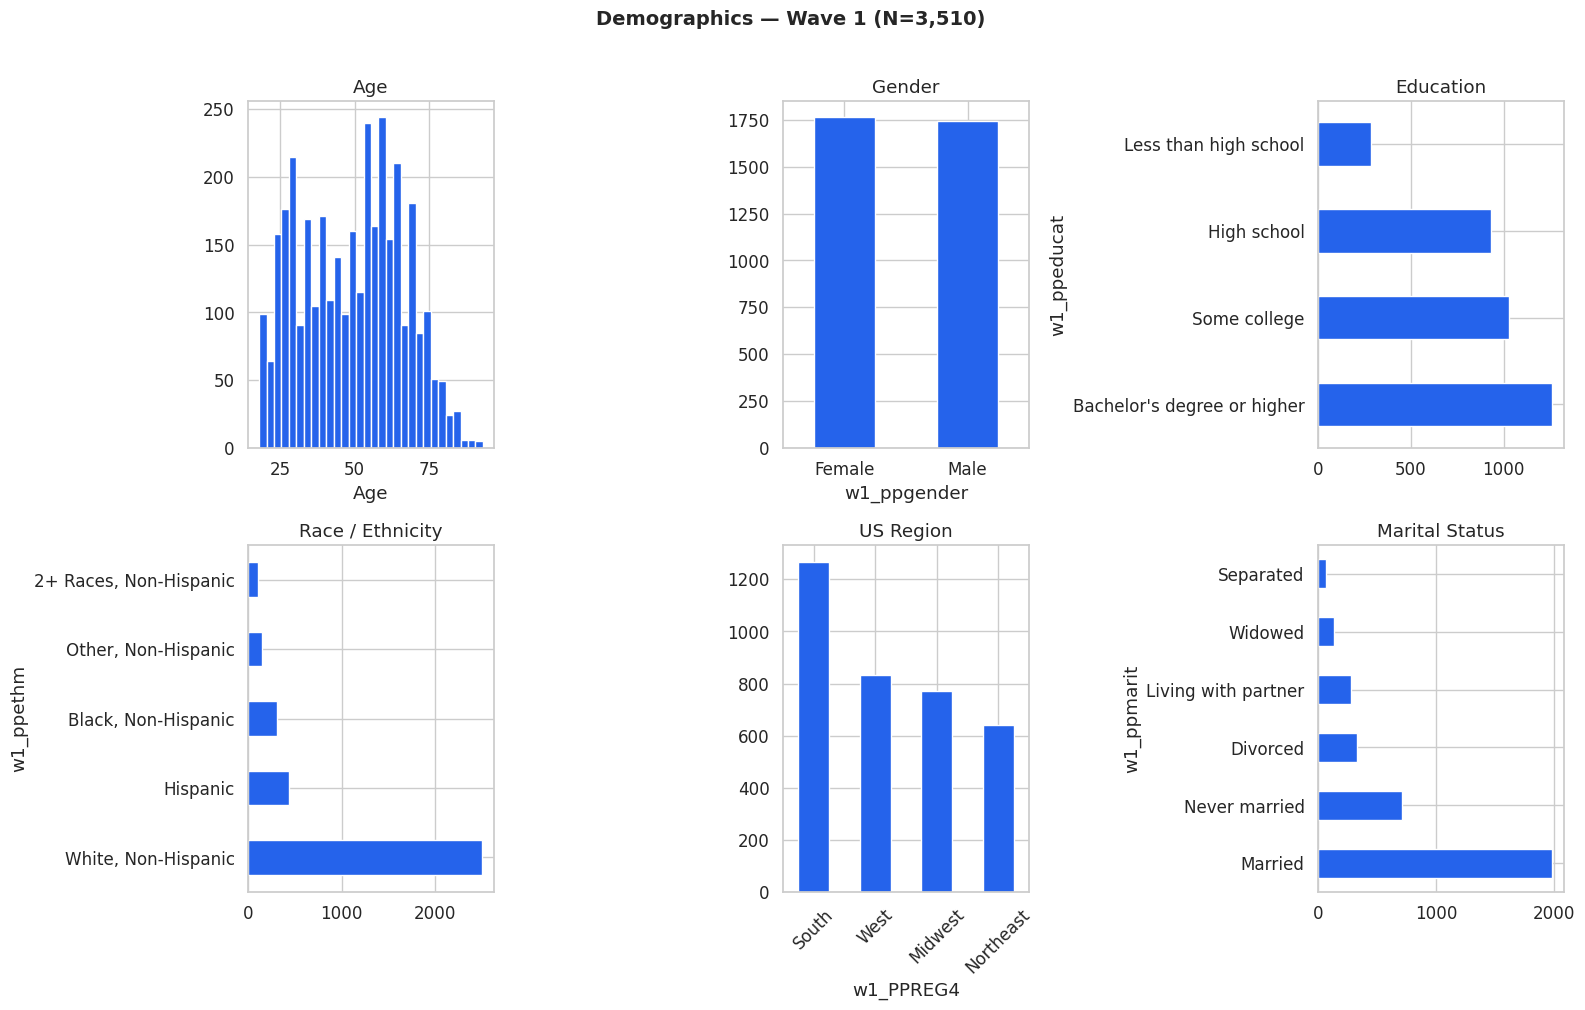

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age
axes[0, 0].hist(df["w1_ppage"], bins=30, color=PALETTE, edgecolor="white")
axes[0, 0].set_title("Age")
axes[0, 0].set_xlabel("Age")

# Gender
gender_counts = label_column(df["w1_ppgender"], "w1_ppgender").value_counts()
gender_counts.plot.bar(ax=axes[0, 1], color=PALETTE)
axes[0, 1].set_title("Gender")
axes[0, 1].tick_params(axis="x", rotation=0)

# Education
edu_counts = label_column(df["w1_ppeducat"], "w1_ppeducat").value_counts()
edu_counts.plot.barh(ax=axes[0, 2], color=PALETTE)
axes[0, 2].set_title("Education")

# Race/Ethnicity
race_counts = label_column(df["w1_ppethm"], "w1_ppethm").value_counts()
race_counts.plot.barh(ax=axes[1, 0], color=PALETTE)
axes[1, 0].set_title("Race / Ethnicity")

# Region
region_counts = label_column(df["w1_PPREG4"], "w1_PPREG4").value_counts()
region_counts.plot.bar(ax=axes[1, 1], color=PALETTE)
axes[1, 1].set_title("US Region")
axes[1, 1].tick_params(axis="x", rotation=45)

# Marital Status
marit_counts = label_column(df["w1_ppmarit"], "w1_ppmarit").value_counts()
marit_counts.plot.barh(ax=axes[1, 2], color=PALETTE)
axes[1, 2].set_title("Marital Status")

plt.suptitle("Demographics — Wave 1 (N=3,510)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### How couples met

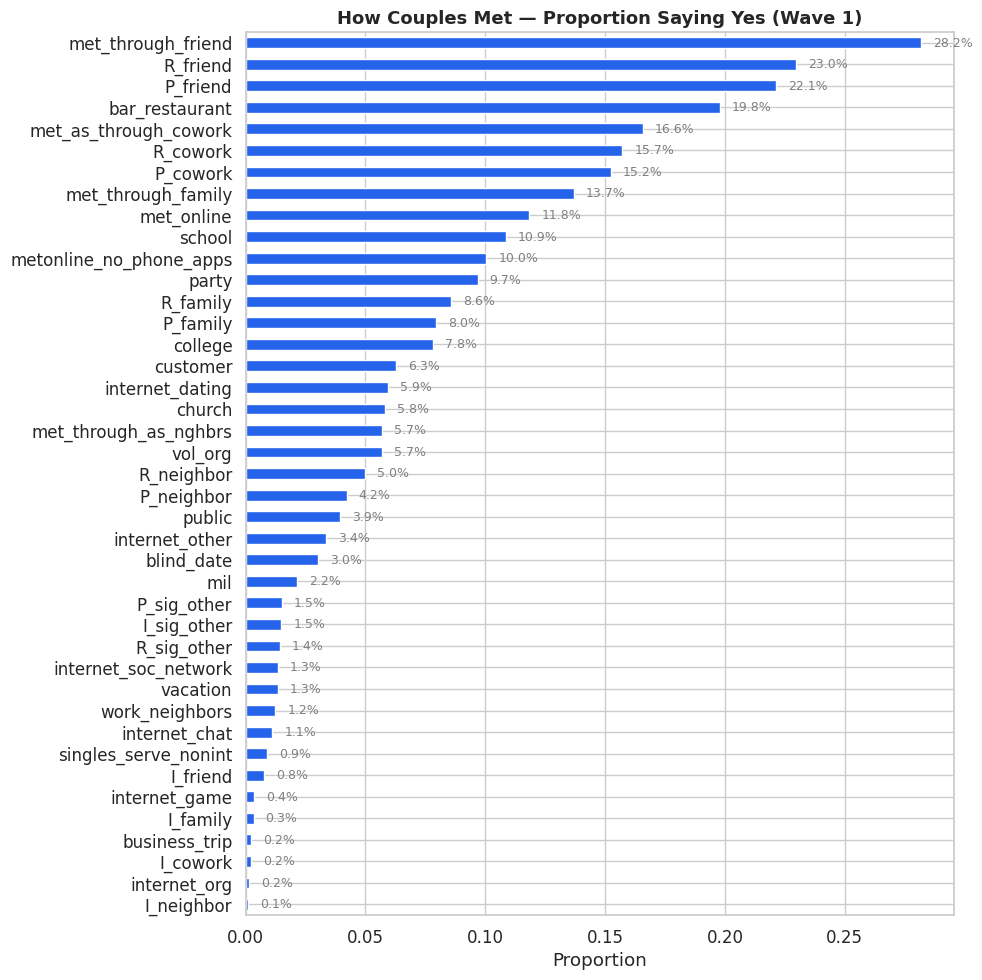

In [12]:
# All w1_q24_ binary variables
how_met_cols = [
    c
    for c in df.columns
    if c.startswith("w1_q24_")
    and c != "w1_q24_length"
    and "summary" not in c
    and "test" not in c
]

# Calculate proportion who said "yes" for each
met_rates = df[how_met_cols].mean().sort_values(ascending=True)
met_rates.index = [c.replace("w1_q24_", "") for c in met_rates.index]

fig, ax = plt.subplots(figsize=(10, 10))
met_rates.plot.barh(ax=ax, color=PALETTE)
ax.set_title(
    "How Couples Met — Proportion Saying Yes (Wave 1)", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Proportion")

# Add percentage labels
for i, (val, name) in enumerate(zip(met_rates.values, met_rates.index)):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center", fontsize=9, color="gray")

plt.tight_layout()
plt.show()

The online breakdown:

Half of online-met couples used dating sites/apps, the other half used other internet channels. For OKCupid, this means dating platforms captured only about 6% of all couples in 2017.
This data reflects relationships that existed in 2017, not relationships that started in 2017. Many of these couples met years or decades ago when online dating barely existed. The younger couples in clustering will likely show much higher online rates. 

### Relationship status and breakdown accros the waves
How did relationship status changed from 2017 to 2022

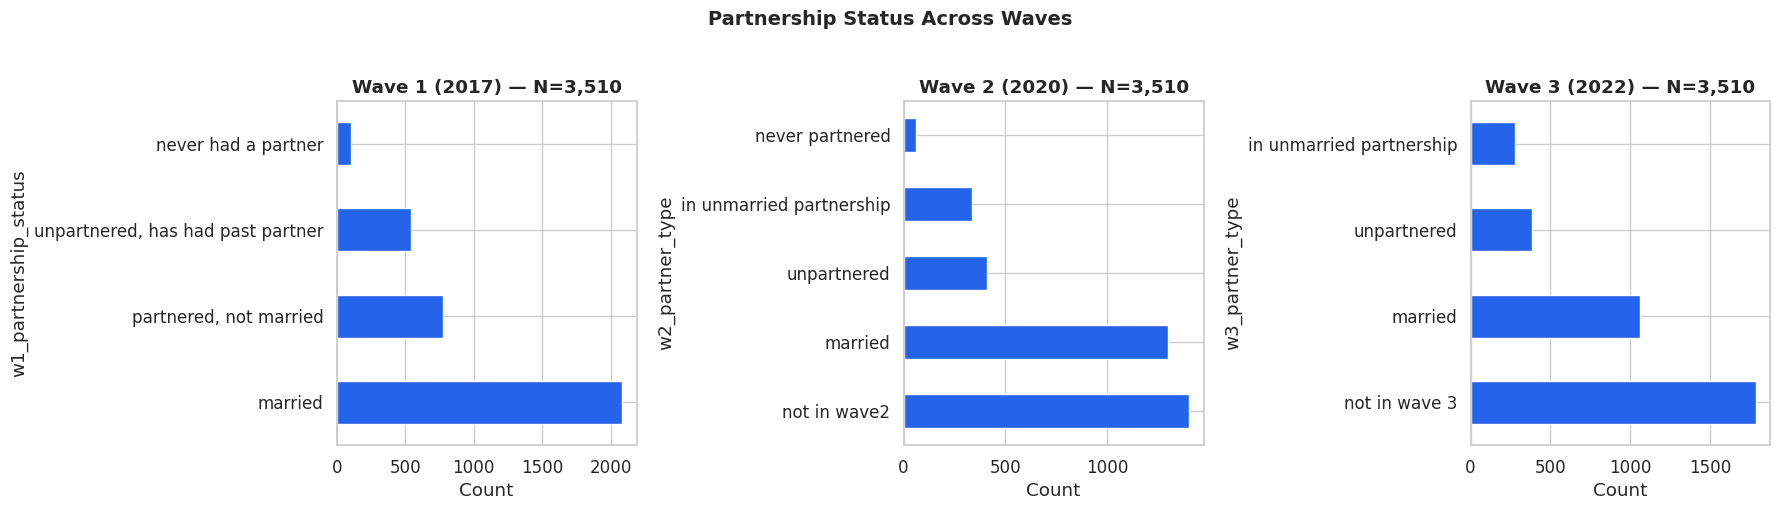

In [13]:
# Partnership status at each wave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in [
    (axes[0], "w1_partnership_status", "Wave 1 (2017) — N=3,510"),
    (axes[1], "w2_partner_type", "Wave 2 (2020) — N=3,510"),
    (axes[2], "w3_partner_type", "Wave 3 (2022) — N=3,510"),
]:
    counts = label_column(df[col], col).value_counts()
    counts.plot.barh(ax=ax, color=PALETTE)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Count")

plt.suptitle("Partnership Status Across Waves", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Relationship quality (Wave 1)
if "w1_q34" in labels:
    qual_labels = labels["w1_q34"]
else:
    qual_labels = {1: "Excellent", 2: "Good", 3: "Fair", 4: "Poor", 5: "Very Poor"}

qual_counts = (
    df["w1_q34"].map({float(k): v for k, v in qual_labels.items()}).value_counts()
)
print("Relationship Quality (Wave 1):")
print(qual_counts)
print(f"\nN = {df['w1_q34'].notna().sum()} (only partnered respondents were asked)")

Relationship Quality (Wave 1):
w1_q34
Excellent    1706
Good          884
Fair          202
Poor           32
Very Poor      23
Name: count, dtype: int64

N = 2847 (only partnered respondents were asked)


### LGB Oversample

In [15]:
# LGB sample flag
lgb_counts = label_column(df["w1_xlgb"], "w1_xlgb").value_counts()
print("Sample composition:")
print(lgb_counts)
print(f"\nLGB proportion in data: {(df['w1_xlgb'] == 1).mean():.1%}")
print("(This is higher than the ~5% in the US population — by design)")

# Same-sex couples
ss_counts = label_column(df["w1_same_sex_couple"], "w1_same_sex_couple").value_counts()
print(f"\nSame-sex couples:")
print(ss_counts)

Sample composition:
w1_xlgb
gen pop       3110
LGB sample     400
Name: count, dtype: int64

LGB proportion in data: 11.4%
(This is higher than the ~5% in the US population — by design)

Same-sex couples:
w1_same_sex_couple
NOT same-sex souple    3086
same_sex_couple         308
Name: count, dtype: int64
